## Sprint 13 — Goal C: bearish-event → breakout-by-industry analysis
Q: around market bearish events, which industries break out, and what do watchlist names return? Signal = LIFT vs baseline, not raw counts.

In [ ]:
# %%  Cell 0 — setup (robust path resolution + sanity check)
import sys
from pathlib import Path

# Walk up from cwd until we find the repo root (the dir containing config.py)
def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for d in (p, *p.parents):
        if (d / "config.py").exists() and (d / "src").is_dir():
            return d
    raise RuntimeError(f"repo root not found above {p}")

ROOT = _repo_root()
sys.path.insert(0, str(ROOT))          # so `import src.db` works from anywhere

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import src.db as db

DB = ROOT / "data" / "market_data.duckdb"      # ABSOLUTE — not cwd-relative
assert DB.exists(), f"DB missing at {DB}"
con = db.connect(str(DB), read_only=True)

# --- sanity check: prove we're on the real 88GB DB before going further ---
print("DB:", DB, f"({DB.stat().st_size/1e9:.1f} GB)")
print(con.execute("""
    select ticker, count(*) n, min(date) lo, max(date) hi
    from price_data where ticker in ('QQQ','SPY','^GSPC') group by ticker
""").df())


DB: C:\Users\sh019\Documents\projects\mm-strat\data\market_data.duckdb (88.7 GB)
  ticker     n         lo         hi
0  ^GSPC  9184 1990-01-02 2026-06-22
1    SPY  8405 1993-01-29 2026-06-22
2    QQQ  6863 1999-03-10 2026-06-22


In [17]:
# --- knobs ---
BENCH      = "QQQ"
START      = "2010-01-01"
BEAR_Q     = 0.05
EVENT_GAP  = 5
PRE, POST  = 30, 20
FWD_H      = 20

QQQ daily-return 5% cutoff = -2.072%   (mean 0.079%, std 1.300%)


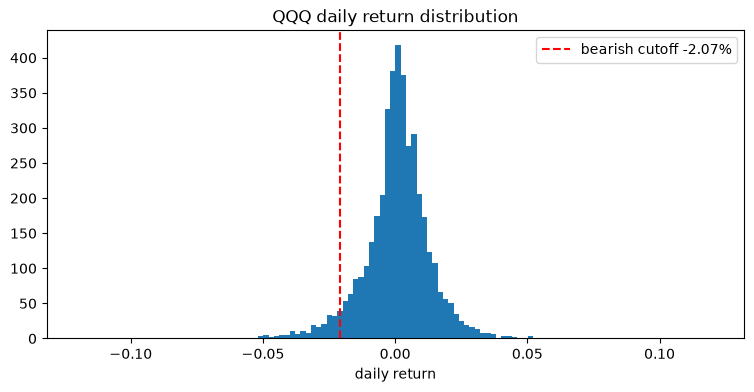

In [18]:
# %%  Cell 1 — benchmark daily returns + distribution
bench = con.execute("""
    select date, close
    from price_data
    where ticker = ? and date >= ?
    order by date
""", [BENCH, START]).df()
bench["ret"] = bench["close"].pct_change()
bench = bench.dropna().reset_index(drop=True)


cut = bench["ret"].quantile(BEAR_Q)
print(f"{BENCH} daily-return {BEAR_Q:.0%} cutoff = {cut:.3%}   "
      f"(mean {bench.ret.mean():.3%}, std {bench.ret.std():.3%})")

fig, ax = plt.subplots(figsize=(9,4))
ax.hist(bench["ret"], bins=120)
ax.axvline(cut, color="r", ls="--", label=f"bearish cutoff {cut:.2%}")
ax.set(title=f"{BENCH} daily return distribution", xlabel="daily return")
ax.legend(); plt.show()


In [19]:
# %%  Cell 2 — classify bearish DAYS, then cluster into EVENTS
bear = bench[bench["ret"] <= cut].copy()
# row index in the trading-day series → gap detection
bench["i"] = np.arange(len(bench))
bear = bear.merge(bench[["date","i"]], on="date")
bear["new_event"] = bear["i"].diff().gt(EVENT_GAP).fillna(True)
bear["event_id"]  = bear["new_event"].cumsum()

# one row per event = its worst (trough) day
events = (bear.sort_values("ret")
              .groupby("event_id", as_index=False).first()
              .sort_values("date")[["event_id","date","ret"]])
print(f"{len(bear)} bearish days collapsed into {len(events)} events")
events.tail(10)


207 bearish days collapsed into 110 events


,event_id,date,ret
100,100,2024-11-15,-0.023826
101,101,2024-12-18,-0.036077
102,102,2025-01-27,-0.029115
103,103,2025-03-10,-0.038756
104,104,2025-04-04,-0.062109
105,105,2025-10-10,-0.034714
106,106,2025-11-20,-0.023672
107,107,2026-01-20,-0.021247
108,108,2026-03-26,-0.023868
109,109,2026-06-05,-0.048001


In [20]:
# %%  Cell 3 — expand each event into a [date-PRE, date+POST] window
# map trough date -> trading-day index, then slice the bench index for exact trading days
idx = bench.set_index("date")["i"]
rows = []
for _, e in events.iterrows():
    c = idx[e["date"]]
    seg = bench[(bench["i"] >= c-PRE) & (bench["i"] <= c+POST)]
    rows.append(pd.DataFrame({"event_id": e["event_id"],
                              "date": seg["date"].values,
                              "offset": seg["i"].values - c}))
windows = pd.concat(rows, ignore_index=True).drop_duplicates("date")
con.register("win", windows[["date"]])     # hand the date set to DuckDB
print(f"{windows['date'].nunique()} unique in-window trading days")


2966 unique in-window trading days


In [23]:
# %%  Cell 4 — breakout rate by industry: in-window vs baseline (LIFT)
# breakout flag lives in t3_sepa_features; industry from company_profiles (current — PIT caveat)
bo = con.execute(f"""
    with b as (
        select t.ticker, t.date, t.breakout,
               (w.date is not null) as in_window
        from t3_sepa_features t
        left join win w using (date)
        where t.date >= '{START}'
    )
    select coalesce(cp.industry,'(unknown)') as industry,
           in_window,
           count(*)                       as n,
           avg(b.breakout)                as breakout_rate
    from b join company_profiles cp using (ticker)
    group by 1,2
""").df()

pivot = bo.pivot(index="industry", columns="in_window", values="breakout_rate")
pivot.columns = ["baseline","in_window"]
pivot["lift"] = abs(pivot["in_window"] / pivot["baseline"] - 1)
pivot = pivot.join(bo.groupby("industry")["n"].sum().rename("n_obs"))
pivot[pivot.n_obs > 5000].sort_values("lift", ascending=False).head(20)


,baseline,in_window,lift,n_obs
industry,,,,
Real Estate - Development,0.164277,0.095593,0.418100,6371
Banks - Diversified,0.197957,0.129148,0.347599,20703
Travel Lodging,0.204430,0.135943,0.335017,17591
Staffing & Employment Services,0.181663,0.122259,0.327001,46160
Railroads,0.186789,0.129411,0.307180,28606
Industrial - Distribution,0.183976,0.127682,0.305983,43226
Security & Protection Services,0.170870,0.118785,0.304821,29534
Industrial - Machinery,0.186446,0.130774,0.298597,162096
Renewable Utilities,0.171688,0.120598,0.297576,13883


In [14]:
# %%  Cell 5 — forward return of BREAKOUT names, in-window, by industry
# fwd return from price_data over FWD_H trading days; survivorship caveat applies
fwd = con.execute(f"""
    with px as (
        select ticker, date, adj_close,
               lead(adj_close, {FWD_H}) over (partition by ticker order by date) as px_fwd
        from price_data
    ),
    breaks as (
        select t.ticker, t.date
        from t3_sepa_features t
        join win w using (date)              -- breakouts INSIDE bearish windows
        where t.breakout = 1 and t.date >= '{START}'
    )
    select coalesce(cp.industry,'(unknown)') as industry,
           count(*)                              as n_breakouts,
           median(px.px_fwd/px.adj_close - 1)    as med_fwd_ret,
           avg(px.px_fwd/px.adj_close - 1)       as avg_fwd_ret
    from breaks
    join px           using (ticker, date)
    join company_profiles cp using (ticker)
    where px.px_fwd is not null
    group by 1
    having count(*) >= 30
    order by med_fwd_ret desc
""").df()
fwd


,industry,n_breakouts,med_fwd_ret,avg_fwd_ret


In [15]:
# %%  Cell 6 — the HONEST view: actual watchlist entries during bearish windows
# screener_watchlist already carries realized pct_return + industry
wl = con.execute("""
    select coalesce(sw.industry,'(unknown)') as industry,
           count(*)                  as n,
           median(sw.pct_return)     as med_ret,
           avg(sw.pct_return)        as avg_ret,
           avg(sw.days_held)         as avg_days
    from screener_watchlist sw
    join win w on sw.entry_date = w.date     -- entered during a bearish window
    group by 1
    having count(*) >= 5
    order by med_ret desc
""").df()
wl


,industry,n,med_ret,avg_ret,avg_days
0,Luxury Goods,29,3.896104,13.463327,70.758621
1,Copper,12,3.710703,7.928078,59.000000
2,Oil & Gas Integrated,20,2.267700,4.395408,59.950000
3,Tobacco,30,1.281989,1.204032,57.333333
4,Investment - Banking & Investment Services,13,0.854166,7.806507,62.769231
...,...,...,...,...,...
134,Gold,57,-5.974451,5.021964,40.807018
135,Solar,34,-7.010649,7.558017,43.176471
136,Medical - Equipment & Services,11,-7.752146,-6.102064,36.181818
137,Uranium,8,-10.896088,-13.606505,34.375000


In [16]:
# %%  Cell 7 — takeaway scaffold
print("Industries with breakout-rate lift > 1.3 in bearish windows:")
print(pivot[(pivot.lift > 1.3) & (pivot.n_obs > 5000)].index.tolist())
# Cross-check: do those same industries show positive med_fwd_ret in Cell 5 / Cell 6?
# If lift is high but fwd-return is not -> breakouts cluster but fail (bull trap).


Industries with breakout-rate lift > 1.3 in bearish windows:
[]
